In [60]:
from cProfile import label

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams
from pathlib import Path
OUTPUT_DIR = Path('outputs')
OUTPUT_DIR.mkdir(exist_ok=True)
rcParams['font.sans-serif'] = ['SimHei']
def savefig(name):
    plt.savefig(OUTPUT_DIR / f'{name}.png', dpi=200, bbox_inches='tight')
df = pd.read_csv('./train.csv')
print(df.head())
print(df.info())
print(df.describe())
print(df.isna().sum().sort_values(ascending=False))

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
<c

In [61]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df['HasCabin'] = df['Cabin'].notna().astype(int)
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['Sex'] = df['Sex'].astype('category')
df['Embarked'] = df['Embarked'].astype('category')
print(df.isna().sum().sort_values(ascending=False))
print(df['HasCabin'].value_counts())

Cabin          687
PassengerId      0
Pclass           0
Name             0
Sex              0
Survived         0
Age              0
SibSp            0
Ticket           0
Parch            0
Fare             0
Embarked         0
HasCabin         0
FamilySize       0
dtype: int64
HasCabin
0    687
1    204
Name: count, dtype: int64


Sex
female    0.74
male      0.19
Name: Survived, dtype: float64


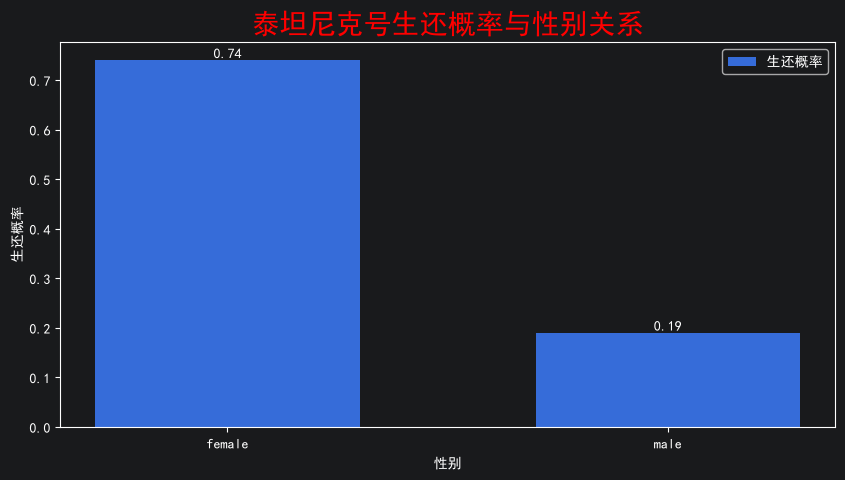

In [62]:
sex_survival = df.groupby('Sex')['Survived'].mean().round(2)
print(sex_survival)
plt.figure(figsize=(10,5))
plt.bar(sex_survival.index,sex_survival.values,label='生还概率',width=0.6)
plt.title('泰坦尼克号生还概率与性别关系',color='red',fontsize=20)
plt.xlabel('性别',fontsize=10)
plt.ylabel('生还概率',fontsize=10)
plt.legend(loc='upper right')
for x,y in zip(sex_survival.index,sex_survival.values):
    plt.text(x,y,str(y),ha='center',va='bottom',fontsize=10)
savefig('sex_survival')
plt.show()

可以看出确实如电影所表现的那样，"women and children first"，女性的生还概率远高于男性

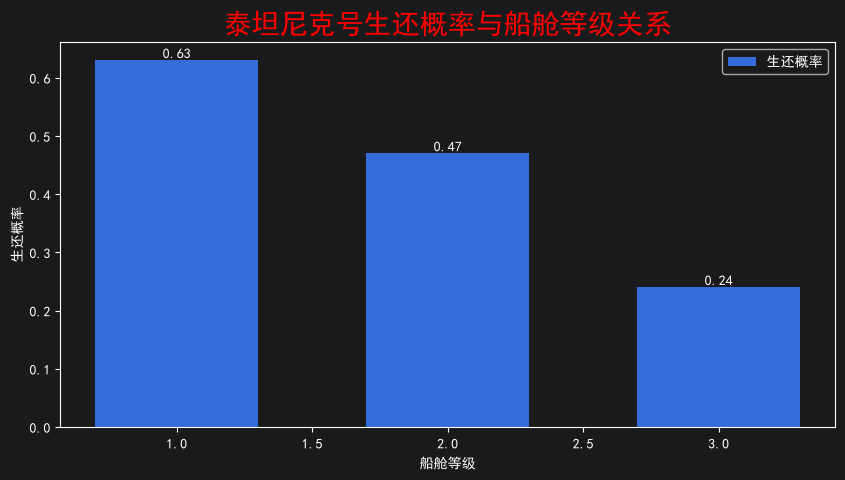

In [63]:
pclass_survival = df.groupby('Pclass')['Survived'].mean().round(2)
plt.figure(figsize=(10,5))
plt.bar(pclass_survival.index,pclass_survival.values,label='生还概率',width=0.6)
plt.title('泰坦尼克号生还概率与船舱等级关系',color='red',fontsize=20)
plt.xlabel('船舱等级',fontsize=10)
plt.ylabel('生还概率',fontsize=10)
plt.legend(loc='upper right')
for x,y in zip(pclass_survival.index,pclass_survival.values):
    plt.text(x,y,str(y),ha='center',va='bottom',fontsize=10)
savefig('pclass_survival')
plt.show()

生还概率一等舱>二等舱>三等舱，梯度明显，可能是因为低等舱更靠近底部，不易逃生。社会地位与财富等级也会影响生死

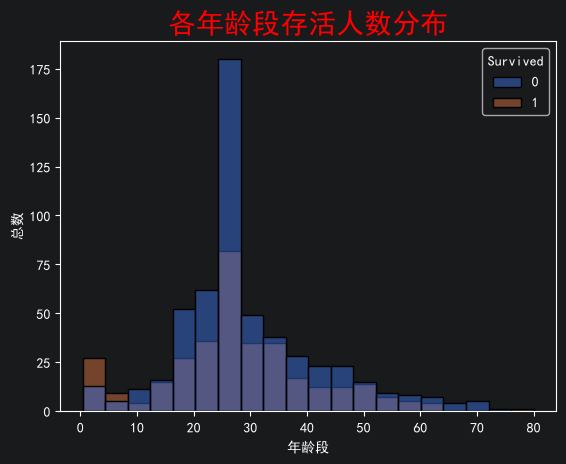

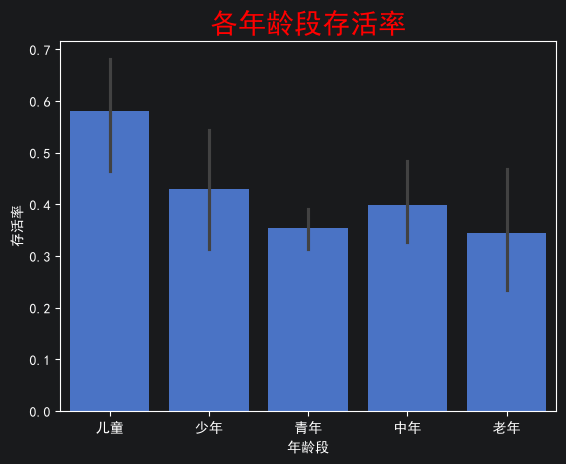

In [64]:
sns.histplot(data=df, x='Age', hue='Survived', bins=20)
plt.title('各年龄段存活人数分布',color='red',fontsize=20)
plt.xlabel('年龄段')
plt.ylabel('总数')
savefig('age_survived')
plt.show()
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 12, 18, 35, 50, 80],labels=['儿童', '少年', '青年', '中年', '老年'])
sns.barplot(data=df, x='AgeGroup', y='Survived')
plt.title('各年龄段存活率',color='red',fontsize=20)
plt.xlabel('年龄段')
plt.ylabel('存活率')
savefig('age_survival')
plt.show()

可以看出，0-10岁儿童存活人数超过死亡人数，而20-35岁青壮年死亡远超存活。儿童和少年的存活率也是最高的，而青壮年作为体力最强的群体反而死亡最多，存活率较低，侧面印证了他们把逃生机会让给了妇孺。

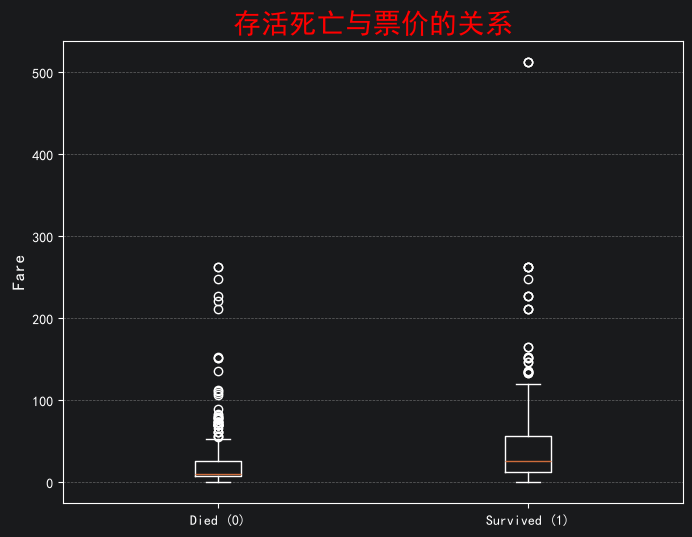

In [65]:
fare_dead = df[df.Survived == 0]['Fare']
fare_survived = df[df.Survived == 1]['Fare']
plt.figure(figsize=(8, 6))
plt.boxplot([fare_dead, fare_survived], tick_labels=['Died (0)', 'Survived (1)'])
plt.title('存活死亡与票价的关系',color='red',fontsize=20)
plt.ylabel('Fare',fontsize=12)
plt.grid(True,axis='y',linestyle='--',alpha=0.5)
savefig('fare_survived')
plt.show()

死亡乘客中绝大多数买的是低价票，箱体压缩在底部存活乘客的票价整体分布明显偏高。两组都有很多离群点，说明有少数高价票乘客死亡、也有低价票乘客幸存，但整体趋势非常明显。

Embarked
C    0.55
Q    0.39
S    0.34
Name: Survived, dtype: float64


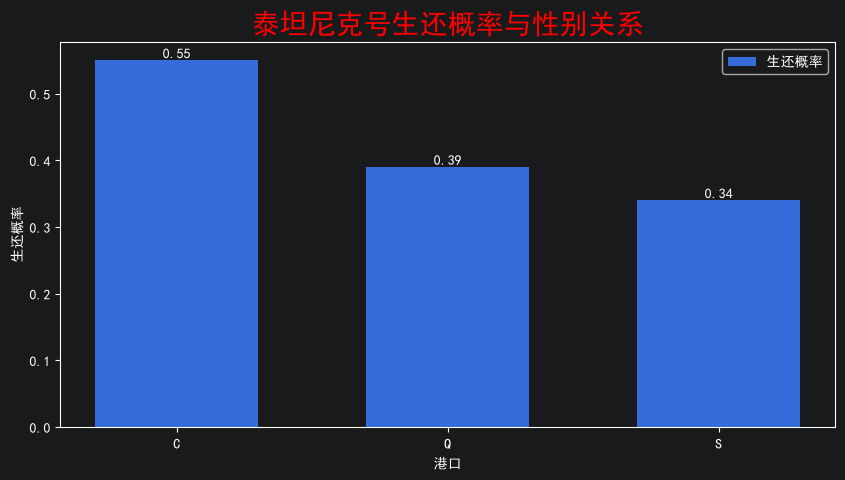

Pclass       1     2     3
Embarked                  
C         0.51  0.10  0.39
Q         0.03  0.04  0.94
S         0.20  0.25  0.55


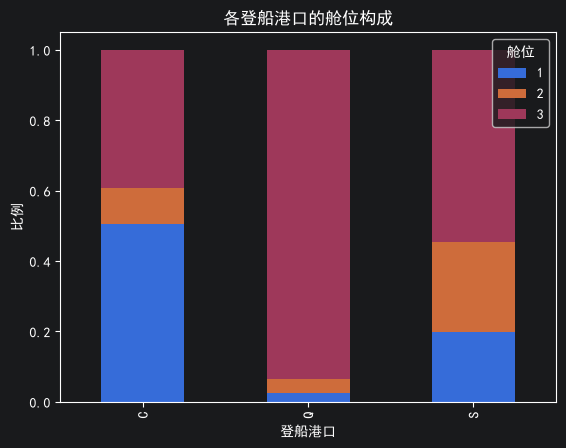

In [66]:
embarked_survived = df.groupby('Embarked')['Survived'].mean().round(2)
print(embarked_survived)
plt.figure(figsize=(10,5))
plt.bar(embarked_survived.index,embarked_survived.values,label='生还概率',width=0.6)
plt.title('泰坦尼克号生还概率与性别关系',color='red',fontsize=20)
plt.xlabel('港口',fontsize=10)
plt.ylabel('生还概率',fontsize=10)
plt.legend(loc='upper right')
for x,y in zip(embarked_survived.index,embarked_survived.values):
    plt.text(x,y,str(y),ha='center',va='bottom',fontsize=10)
savefig('embarked_survived')
plt.show()
print(pd.crosstab(df['Embarked'], df['Pclass'], normalize='index').round(2))
ct = pd.crosstab(df['Embarked'], df['Pclass'], normalize='index')
ct.plot(kind='bar',stacked=True)
plt.title('各登船港口的舱位构成')
plt.ylabel('比例')
plt.xlabel('登船港口')
plt.legend(title='舱位')
savefig('embarked_pclass')
plt.show()

可以看出从c港口上船的人存活率远高于其他港口上船的人。这看起来没什么道理，但经过进一步研究可以发现存活比例最高的c港一等舱占比也是最高,所以这实际上还是财力与生还概率的相关。

            count      mean
FamilySize                 
1             537  0.303538
2             161  0.552795
3             102  0.578431
4              29  0.724138
5              15  0.200000
6              22  0.136364
7              12  0.333333
8               6  0.000000
11              7  0.000000


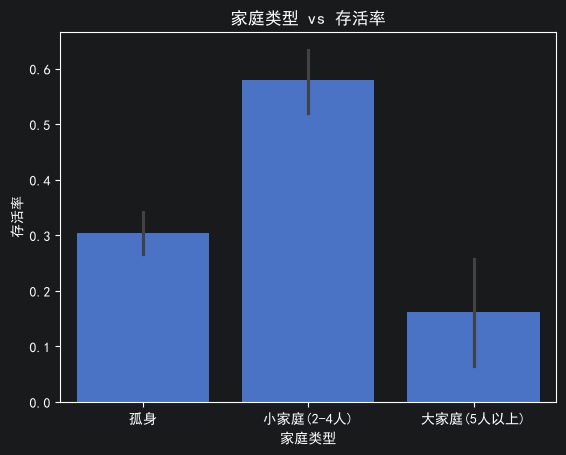

In [67]:
print(df.groupby('FamilySize')['Survived'].agg(['count', 'mean']))
df['FamilyGroup'] = pd.cut(df['FamilySize'], bins=[0, 1, 4, 11],
                           labels=['孤身', '小家庭(2-4人)', '大家庭(5人以上)'])
sns.barplot(data=df, x='FamilyGroup', y='Survived', order=['孤身', '小家庭(2-4人)', '大家庭(5人以上)'])
plt.title('家庭类型 vs 存活率')
plt.xlabel('家庭类型')
plt.ylabel('存活率')
savefig('familygroup_survival')
plt.show()

可以看出家庭规模与存活率呈倒U形关系：2-4人小家庭存活率最高，孤身乘客和5人以上大家庭均明显偏低。可能是因为小家庭可以相互扶持，但大家庭人太多反而耽误了逃生时间。